In [2]:
import pandas as pd
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
# import PSDProd as prod
# import csvCleaner as cleaner
# import interaction as inter
import os
import sys
import datetime

In [3]:
tresDF = pd.read_csv('../SDCardOut/tres/concurrentTRES3.CSV')
tresDF

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor
0,260415_180640_000,65200.000,0.0000,NaN,0.0000,NaN,5667
1,260415_180640_447,65200.445,0.0000,NaN,0.0000,NaN,13590
2,260415_180640_546,65200.547,0.0000,NaN,0.0000,NaN,10497
3,260415_180640_646,65200.645,0.0000,NaN,0.0000,NaN,2360
4,260415_180640_746,65200.746,0.0000,NaN,0.0000,NaN,1766
...,...,...,...,...,...,...,...
86206,260415_203021_500,73821.500,4159.9902,N,8739.4629,W,8196
86207,260415_203021_600,73821.602,4159.9902,N,8739.4629,W,8263
86208,260415_203021_700,73821.703,4159.9902,N,8739.4629,W,8179
86209,260415_203021_800,73821.797,4159.9902,N,8739.4629,W,8262


In [4]:
secs = np.array(tresDF['seconds'][12000:-12000])
sens = np.array(tresDF['sensor'][12000:-12000])
volt = sens * 5 / 16383

[]

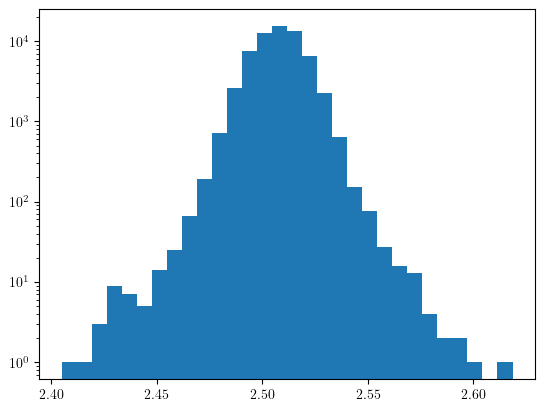

In [5]:
plt.hist(volt,bins=30)
plt.semilogy()

In [6]:
print(f'1%: {np.percentile(volt,1)}, 50%: {np.percentile(volt,50)}, 99%: {np.percentile(volt,99)}')

1%: 2.4803149606299213, 50%: 2.5080876518342183, 99%: 2.5352499542208387


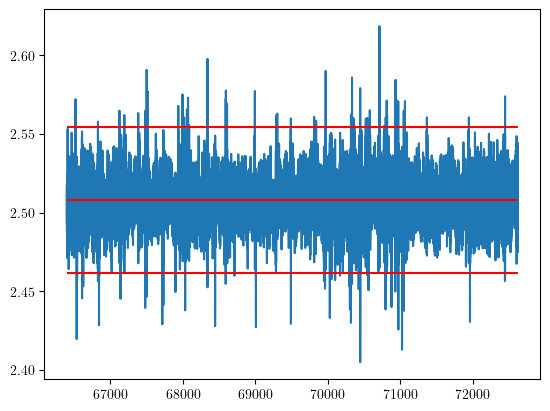

In [7]:
plt.plot(secs,volt)
plt.hlines([np.percentile(volt,0.1),np.percentile(volt,50),np.percentile(volt,99.9)],secs.min(),secs.max(),colors='red')

In [8]:
indList = []
for i in range(len(volt)):
    if (volt[i] <= np.percentile(volt,0.1)) or (volt[i] >= np.percentile(volt,99.9)):
        indList.append(i)

In [9]:
def windowMaker(arr,idxarr,halfWIndex=500):
    # kind of a big function but it should output lists of arrays with event and background segregated
    # first need to make some cutoff indices
    noiseWIndex = []
    eventWIndex = []
    n = len(arr)

    # now we construct prelim event windows
    for idx in idxarr:
        low = max(0,int(idx-halfWIndex))
        high = min(n-1,int(idx+halfWIndex))
        eventWIndex.append([low,high])
    
    # then here we merge if any overlap
    eventWIndex.sort(key=lambda w: w[0])
    merged = []
    for low, high in eventWIndex:
        if not merged or low > merged[-1][1] + 1:
            merged.append([low,high])
        else:
            merged[-1][1] = max(merged[-1][1],high)
    
    eventWIndex = merged

    # now the remaining values are all background noise
    cursor = 0
    for low,high in eventWIndex:
        if cursor < low:
            noiseWIndex.append([cursor,low-1])
        cursor = high + 1 
    
    if cursor <= n-1:
        noiseWIndex.append([cursor,n-1])
    
    # enforce these windows upon the voltage and seconds arrs
    noiseArrs = []
    for low,high in noiseWIndex:
        noiseArrs.append(arr[low:high])
    eventArrs = []
    for low,high in eventWIndex:
        eventArrs.append(arr[low:high])

    return eventArrs,noiseArrs

In [10]:
eventWin,noiseWin = windowMaker(volt,indList)
eventSec,noiseSec = windowMaker(secs,indList)

(2.404931941646829, 2.61856802783373)

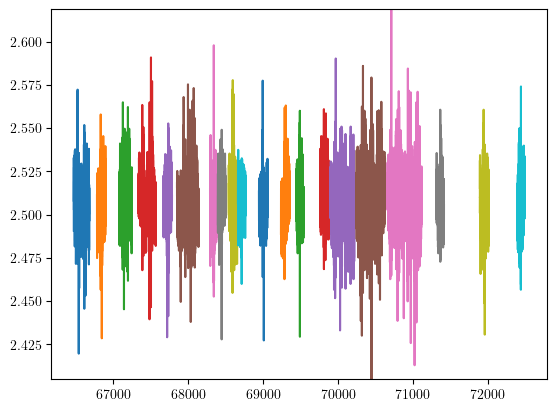

In [11]:
for i in range(len(eventWin)):
    plt.plot(eventSec[i],eventWin[i])

plt.ylim(volt.min(),volt.max())

(2.404931941646829, 2.61856802783373)

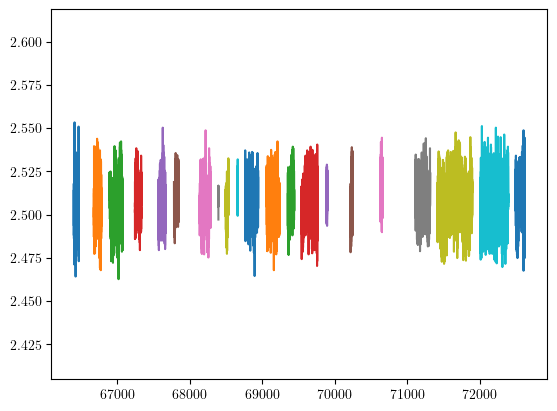

In [12]:
for i in range(len(noiseWin)):
    plt.plot(noiseSec[i],noiseWin[i])

plt.ylim(volt.min(),volt.max())

In [28]:
flatEventSec = []
for event in eventSec:
    for sec in event:
        flatEventSec.append(sec)

flatEventSec = np.array(flatEventSec)


In [29]:
flatEventSec

array([66469.398, 66469.5  , 66469.602, ..., 72496.102, 72496.203,
       72496.297], shape=(34760,))

(array([2009.,  978.,  248., 1681., 1391.,  995., 1341., 2009.,  605.,
        1860., 1521.,  841., 1149.,  436., 1130.,  589., 1224., 1924.,
        1704., 2009., 1680., 2009., 2009.,  251., 1000.,    0.,    0.,
        1153.,    0., 1014.]),
 array([66469.398     , 66670.29463333, 66871.19126667, 67072.0879    ,
        67272.98453333, 67473.88116667, 67674.7778    , 67875.67443333,
        68076.57106667, 68277.4677    , 68478.36433333, 68679.26096667,
        68880.1576    , 69081.05423333, 69281.95086667, 69482.8475    ,
        69683.74413333, 69884.64076667, 70085.5374    , 70286.43403333,
        70487.33066667, 70688.2273    , 70889.12393333, 71090.02056667,
        71290.9172    , 71491.81383333, 71692.71046667, 71893.6071    ,
        72094.50373333, 72295.40036667, 72496.297     ]),
 <BarContainer object of 30 artists>)

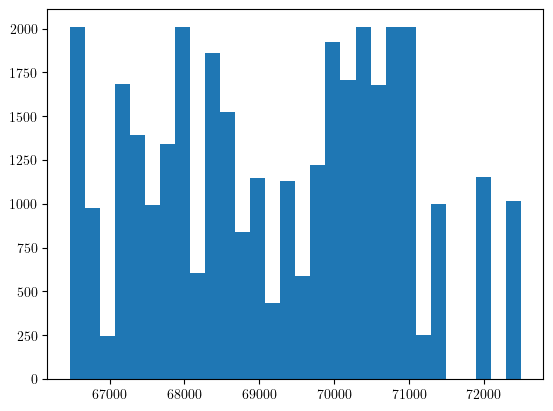

In [30]:
plt.hist(flatEventSec,bins = 30)